# Chapter 5: Architecture

With the mathematical and physical groundwork in place, we turn to the nuts and bolts of quantum computing. A classical computer lives and dies by its bits. A quantum computer lives and dies by a richer object, the qubit, and the gates that manipulate it.

This chapter walks through four layers of that story:
1. **Bits and qubits** as column vectors
2. **Classical gates** recast as matrices
3. **Reversible gates** (CNOT, Toffoli, Fredkin) and why reversibility matters
4. **Quantum gates** (Pauli, Hadamard, phase shifts, controlled-U, the Deutsch gate) and the No-Cloning Theorem

Every gate is built as a numpy matrix and verified computationally.

In [1]:
import numpy as np
from numpy import array, eye, zeros, kron, sqrt, conj, pi, cos, sin, exp
from numpy.linalg import norm
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

def is_unitary(U, tol=1e-10):
    """Check whether a matrix is unitary: U^dagger @ U = I."""
    n = U.shape[0]
    return np.allclose(U.conj().T @ U, eye(n), atol=tol)

def is_own_inverse(U, tol=1e-10):
    """Check whether U @ U = I (the gate is its own inverse)."""
    n = U.shape[0]
    return np.allclose(U @ U, eye(n), atol=tol)

# Basis states
ket0 = array([[1], [0]])
ket1 = array([[0], [1]])

## 5.1 Bits and Qubits

A bit describes a system with exactly two states. Electricity flows through a wire or it does not. A switch is on or off. A proposition is true or false. We write these two states as 0 and 1, and represent them as column vectors:

$$|0\rangle = \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \qquad |1\rangle = \begin{bmatrix} 0 \\ 1 \end{bmatrix}.$$

These are orthogonal unit vectors in $\mathbb{C}^2$, so any vector in that space can be decomposed as $c_0|0\rangle + c_1|1\rangle$.

In [2]:
# Bits as column vectors
print("|0> =", ket0.flatten())
print("|1> =", ket1.flatten())
print("Orthogonal:", np.vdot(ket0, ket1) == 0)

|0> = [1 0]
|1> = [0 1]
Orthogonal: True


In the classical world, either/or is enough. In the quantum world, a system can be in *both* states simultaneously. A **qubit** is a unit of information describing a two-dimensional *quantum* system. We represent it as a column vector

$$|\psi\rangle = \begin{bmatrix} c_0 \\ c_1 \end{bmatrix} = c_0|0\rangle + c_1|1\rangle,$$

where $|c_0|^2 + |c_1|^2 = 1$. The squared magnitudes give measurement probabilities: $|c_0|^2$ is the probability of finding the qubit in state $|0\rangle$, and $|c_1|^2$ the probability of $|1\rangle$. A classical bit is the special case where one coefficient is 1 and the other is 0.

**Example 5.1.1.** The vector $V = [5+3i,\; 6i]^T$ has norm $\sqrt{34+36} = \sqrt{70}$. After normalization it becomes the qubit $\frac{5+3i}{\sqrt{70}}|0\rangle + \frac{6i}{\sqrt{70}}|1\rangle$, with measurement probabilities $34/70$ and $36/70$.

In [3]:
# Example 5.1.1: normalizing a vector into a qubit
V = array([[5+3j], [6j]])
nrm = norm(V)
print(f"Norm = sqrt({int(abs(5+3j)**2 + abs(6j)**2)}) = {nrm:.6f}")
qubit = V / nrm
print(f"Qubit: {qubit.flatten()}")
probs = abs(qubit)**2
print(f"P(|0>) = {probs[0,0]:.6f}, P(|1>) = {probs[1,0]:.6f}")
print(f"Sum = {probs.sum():.6f}")

Norm = sqrt(70) = 8.366600
Qubit: [0.597614+0.358569j 0.      +0.717137j]
P(|0>) = 0.485714, P(|1>) = 0.514286
Sum = 1.000000


Several ways to write the same qubit help build intuition. The equal-superposition state $\frac{1}{\sqrt{2}}[1,1]^T$ can be written as

$$\frac{|0\rangle + |1\rangle}{\sqrt{2}} = \frac{|1\rangle + |0\rangle}{\sqrt{2}},$$

because addition of kets is commutative. But $\frac{|0\rangle - |1\rangle}{\sqrt{2}} \neq \frac{|1\rangle - |0\rangle}{\sqrt{2}}$: the first is $[1/\sqrt{2},\, -1/\sqrt{2}]^T$ and the second is $[-1/\sqrt{2},\, 1/\sqrt{2}]^T$. They differ by a factor of $-1$, so they represent the same physical state (global phase), yet as vectors they are distinct.

### Multi-qubit states and tensor products

A single qubit lives in $\mathbb{C}^2$. To describe $n$ qubits, we take the tensor product of $n$ copies: $(\mathbb{C}^2)^{\otimes n} \cong \mathbb{C}^{2^n}$. A byte (8 classical bits) needs 8 values. A qubyte (8 qubits) needs $2^8 = 256$ complex amplitudes, one per basis state. A 64-qubit register would require $2^{64} \approx 1.8 \times 10^{19}$ amplitudes. This exponential growth is both the promise and the challenge of quantum computing.

Two-qubit ket notation: $|0\rangle \otimes |1\rangle = |01\rangle$ is the 4-vector $[0,1,0,0]^T$.

In [4]:
# Multi-qubit states via tensor product
ket01 = kron(ket0, ket1)
print("|01> =", ket01.flatten())

ket10 = kron(ket1, ket0)
print("|10> =", ket10.flatten())

# Tensor product is NOT commutative
print("\n|01> == |10>?", np.array_equal(ket01, ket10))

# Three-qubit example: |101> = |1> x |0> x |1>
ket101 = kron(kron(ket1, ket0), ket1)
print("\n|101> =", ket101.flatten())

|01> = [0 1 0 0]
|10> = [0 0 1 0]

|01> == |10>? False

|101> = [0 0 0 0 0 1 0 0]


### Entanglement

The state $\frac{|11\rangle + |00\rangle}{\sqrt{2}}$ is entangled: if you measure the first qubit and find $|1\rangle$, you instantly know the second is also $|1\rangle$. No tensor product of single-qubit states can produce this correlation. Separable states factor; entangled states do not.

In [5]:
# Entangled Bell state
ket00 = kron(ket0, ket0)
ket11 = kron(ket1, ket1)
bell = (ket11 + ket00) / sqrt(2)
print("Bell state (|11>+|00>)/sqrt(2) =", bell.flatten())

# Verify it cannot be factored as (a|0>+b|1>) x (c|0>+d|1>)
# That would require coefficients [ac, ad, bc, bd] with ac=bd=1/sqrt(2), ad=bc=0
# ad=0 => a=0 or d=0. But if a=0 then ac=0 != 1/sqrt(2). Contradiction.
print("This state is entangled: it cannot be written as a tensor product of two single-qubit states.")

Bell state (|11>+|00>)/sqrt(2) = [0.707107 0.       0.       0.707107]
This state is entangled: it cannot be written as a tensor product of two single-qubit states.


### Exercises 5.1

**Exercise 5.1.1.** Write $V = [3+2i,\; 4-2i]^T$ as a sum of $|0\rangle$ and $|1\rangle$.

**Solution:** $V = (3+2i)|0\rangle + (4-2i)|1\rangle$.

In [6]:
# Exercise 5.1.1
V = array([[3+2j], [4-2j]])
c0, c1 = V[0,0], V[1,0]
print(f"V = ({c0})|0> + ({c1})|1>")
print("Check:", np.allclose(V, c0*ket0 + c1*ket1))

V = ((3+2j))|0> + ((4-2j))|1>
Check: True


**Exercise 5.1.2.** Normalize $V = [15 - 3.4i,\; 2.1 - 16i]^T$.

**Solution:** Divide by its norm.

In [7]:
# Exercise 5.1.2
V = array([[15 - 3.4j], [2.1 - 16j]])
nrm = norm(V)
qubit = V / nrm
print(f"Norm = {nrm:.5f}")
print(f"Normalized: {qubit.flatten()}")
print(f"Verification: |qubit|^2 sums to {(abs(qubit)**2).sum():.10f}")
# Book answer: (0.67286 - 0.15252i)|0> + (0.09420 - 0.71772i)|1>
print(f"As ket: ({qubit[0,0]:.5f})|0> + ({qubit[1,0]:.5f})|1>")

Norm = 22.29282
Normalized: [0.672862-0.152515j 0.094201-0.71772j ]
Verification: |qubit|^2 sums to 1.0000000000
As ket: (0.67286-0.15252j)|0> + (0.09420-0.71772j)|1>


**Exercise 5.1.3.** Express the three bits 101, 011, and 111 as vectors in $(\mathbb{C}^2)^{\otimes 3} = \mathbb{C}^8$.

**Solution:** Use the tensor product of the individual qubit states.

In [8]:
# Exercise 5.1.3
def ket_from_bits(bits):
    """Build a multi-qubit ket from a string of 0s and 1s."""
    result = ket0 if bits[0] == '0' else ket1
    for b in bits[1:]:
        result = kron(result, ket0 if b == '0' else ket1)
    return result

for bits in ['101', '011', '111']:
    v = ket_from_bits(bits)
    print(f"|{bits}> = {v.flatten()}")

|101> = [0 0 0 0 0 1 0 0]
|011> = [0 0 0 1 0 0 0 0]
|111> = [0 0 0 0 0 0 0 1]


**Exercise 5.1.4.** What vector corresponds to $3|01\rangle + 2|11\rangle$?

**Solution:** $|01\rangle = [0,1,0,0]^T$ and $|11\rangle = [0,0,0,1]^T$, so $3|01\rangle + 2|11\rangle = [0,3,0,2]^T$.

In [9]:
# Exercise 5.1.4
result = 3 * ket_from_bits('01') + 2 * ket_from_bits('11')
print("3|01> + 2|11> =", result.flatten())

3|01> + 2|11> = [0 3 0 2]


## 5.2 Classical Gates

Classical logic gates manipulate bits. We represent $n$ input bits as a $2^n$-by-1 column vector and $m$ output bits as a $2^m$-by-1 vector. A gate with $n$ inputs and $m$ outputs becomes a $2^m \times 2^n$ matrix. Multiplying the gate matrix by the input vector gives the output.

Two composition rules:
- **Sequential** operations (one gate after another): multiply the matrices, $B \cdot A$.
- **Parallel** operations (different gates on different bits): take the tensor product, $A \otimes B$.

### NOT gate

One input, one output. Flips 0 to 1 and 1 to 0.

In [10]:
# NOT gate
NOT = array([[0, 1],
             [1, 0]])

print("NOT|0> =", (NOT @ ket0).flatten(), "= |1>")
print("NOT|1> =", (NOT @ ket1).flatten(), "= |0>")

NOT|0> = [0 1] = |1>
NOT|1> = [1 0] = |0>


### AND gate

Two inputs, one output. Output is 1 only when both inputs are 1. This is a $2^1 \times 2^2 = 2 \times 4$ matrix.

In [11]:
# AND gate
AND = array([[1, 1, 1, 0],
             [0, 0, 0, 1]])

for bits in ['00', '01', '10', '11']:
    inp = ket_from_bits(bits)
    out = AND @ inp
    print(f"AND|{bits}> = {out.flatten()}")

AND|00> = [1 0]
AND|01> = [1 0]
AND|10> = [1 0]
AND|11> = [0 1]


### OR gate

Two inputs, one output. Output is 1 when at least one input is 1.

In [12]:
# OR gate
OR = array([[1, 0, 0, 0],
            [0, 1, 1, 1]])

for bits in ['00', '01', '10', '11']:
    inp = ket_from_bits(bits)
    out = OR @ inp
    print(f"OR|{bits}> = {out.flatten()}")

OR|00> = [1 0]
OR|01> = [0 1]
OR|10> = [0 1]
OR|11> = [0 1]


### NAND gate

The NAND gate is AND followed by NOT. Every classical gate can be built from NAND gates alone, making it **universal**.

$$\text{NAND} = \text{NOT} \cdot \text{AND} = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} \begin{bmatrix} 1 & 1 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} = \begin{bmatrix} 0 & 0 & 0 & 1 \\ 1 & 1 & 1 & 0 \end{bmatrix}.$$

In [13]:
# NAND = NOT * AND
NAND = NOT @ AND
print("NAND =")
print(NAND)

for bits in ['00', '01', '10', '11']:
    inp = ket_from_bits(bits)
    out = NAND @ inp
    print(f"NAND|{bits}> = {out.flatten()}")

NAND =
[[0 0 0 1]
 [1 1 1 0]]
NAND|00> = [0 1]
NAND|01> = [0 1]
NAND|10> = [0 1]
NAND|11> = [1 0]


### NOR gate

NOR is OR followed by NOT.

In [14]:
# NOR = NOT * OR
NOR = NOT @ OR
print("NOR =")
print(NOR)

for bits in ['00', '01', '10', '11']:
    inp = ket_from_bits(bits)
    out = NOR @ inp
    print(f"NOR|{bits}> = {out.flatten()}")

NOR =
[[0 1 1 1]
 [1 0 0 0]]
NOR|00> = [0 1]
NOR|01> = [1 0]
NOR|10> = [1 0]
NOR|11> = [1 0]


### Sequential and parallel composition

When gate $A$ is followed by gate $B$, the combined operation is $B \cdot A$ (matrix multiplication, right to left). When gate $A$ acts on some bits while gate $B$ acts on others in parallel, the combined operation is $A \otimes B$ (tensor product).

A key identity links the two: $(B \otimes B') \cdot (A \otimes A') = (B \cdot A) \otimes (B' \cdot A')$.

### DeMorgan's laws in matrix form

DeMorgan's first law: $\neg(\neg P \wedge \neg Q) = P \vee Q$. In matrix terms:

$$\text{NOT} \cdot \text{AND} \cdot (\text{NOT} \otimes \text{NOT}) = \text{OR}.$$

In [15]:
# DeMorgan's law: NOT * AND * (NOT x NOT) = OR
NOT_x_NOT = kron(NOT, NOT)
print("NOT x NOT =")
print(NOT_x_NOT)

demorgan1 = NOT @ AND @ NOT_x_NOT
print("\nNOT * AND * (NOT x NOT) =")
print(demorgan1)
print("\nEquals OR?", np.array_equal(demorgan1, OR))

NOT x NOT =
[[0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]
 [1 0 0 0]]

NOT * AND * (NOT x NOT) =
[[1 0 0 0]
 [0 1 1 1]]

Equals OR? True


**Example 5.2.2.** A circuit with a NOT on one wire and AND on two others, followed by an OR gate, is represented by $\text{OR} \cdot (\text{NOT} \otimes \text{AND})$.

In [16]:
# Example 5.2.2: OR * (NOT x AND)
NOT_x_AND = kron(NOT, AND)
print("NOT x AND shape:", NOT_x_AND.shape)
print(NOT_x_AND)

circuit = OR @ NOT_x_AND
print("\nOR * (NOT x AND) =")
print(circuit)

NOT x AND shape: (4, 8)
[[0 0 0 0 1 1 1 0]
 [0 0 0 0 0 0 0 1]
 [1 1 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]]

OR * (NOT x AND) =
[[0 0 0 0 1 1 1 0]
 [1 1 1 1 0 0 0 1]]


### Exercises 5.2

**Exercise 5.2.1.** Calculate $\text{AND}|10\rangle$.

**Solution:** $|10\rangle = [0,0,1,0]^T$. $\text{AND}|10\rangle = |0\rangle$.

In [17]:
# Exercise 5.2.1
print("AND|10> =", (AND @ ket_from_bits('10')).flatten())

AND|10> = [1 0]


**Exercise 5.2.2.** Show that the OR matrix performs the OR operation.

**Solution:** Verify on all four inputs.

In [18]:
# Exercise 5.2.2
print("Verifying OR gate on all inputs:")
for bits in ['00', '01', '10', '11']:
    out = OR @ ket_from_bits(bits)
    result = '0' if out[0,0] == 1 else '1'
    expected = '0' if bits == '00' else '1'
    print(f"  OR|{bits}> = |{result}>  (expected |{expected}>): {'OK' if result == expected else 'FAIL'}")

Verifying OR gate on all inputs:
  OR|00> = |0>  (expected |0>): OK
  OR|01> = |1>  (expected |1>): OK
  OR|10> = |1>  (expected |1>): OK
  OR|11> = |1>  (expected |1>): OK


**Exercise 5.2.3.** Find the matrix for NOR.

**Solution:** $\text{NOR} = \text{NOT} \cdot \text{OR}$.

In [19]:
# Exercise 5.2.3
print("NOR = NOT * OR =")
print(NOR)
# Verify
for bits in ['00', '01', '10', '11']:
    out = NOR @ ket_from_bits(bits)
    print(f"  NOR|{bits}> = {out.flatten()}")

NOR = NOT * OR =
[[0 1 1 1]
 [1 0 0 0]]
  NOR|00> = [0 1]
  NOR|01> = [1 0]
  NOR|10> = [1 0]
  NOR|11> = [1 0]


**Exercise 5.2.4.** In Exercise 2.7.4 we proved $A \otimes B \cong B \otimes A$. In the context of circuits, this means it does not matter which operation is "top" and which is "bottom": the wires can be crossed.

**Exercise 5.2.5.** For matrices of appropriate sizes, $(B \otimes B') \cdot (A \otimes A') = (B \cdot A) \otimes (B' \cdot A')$. In circuit terms: doing parallel operations each containing two sequential operations is the same as two sequential operations, each consisting of two parallel operations.

In [20]:
# Exercise 5.2.5: verify (B x B') * (A x A') = (B*A) x (B'*A')
# Using NOT as B, AND as A, OR as B', and some 2x4 matrix as A'
# Let's use concrete sizes: B=NOT (2x2), A=NOT (2x2), B'=AND (2x4), A'=NAND (2x4) won't work.
# Need: columns of A = columns of A', rows of A = cols of B, rows of A' = cols of B'
# Use: A = NOT (2x2), B = NOT (2x2), A' = NOT (2x2), B' = NOT (2x2)
A = NOT; B = NOT; Ap = array([[1,0],[0,-1]]); Bp = array([[0,1],[1,0]])
lhs = kron(B, Bp) @ kron(A, Ap)
rhs = kron(B @ A, Bp @ Ap)
print("(B x B') * (A x A') =")
print(lhs)
print("\n(B*A) x (B'*A') =")
print(rhs)
print("\nEqual?", np.allclose(lhs, rhs))

(B x B') * (A x A') =
[[ 0 -1  0  0]
 [ 1  0  0  0]
 [ 0  0  0 -1]
 [ 0  0  1  0]]

(B*A) x (B'*A') =
[[ 0 -1  0  0]
 [ 1  0  0  0]
 [ 0  0  0 -1]
 [ 0  0  1  0]]

Equal? True


**Exercise 5.2.6.** Verify the DeMorgan identity matrices multiply out correctly.

In [21]:
# Exercise 5.2.6: verify both DeMorgan's laws
# Law 1: NOT * AND * (NOT x NOT) = OR
law1 = NOT @ AND @ kron(NOT, NOT)
print("DeMorgan 1: NOT*AND*(NOTxNOT) = OR?", np.array_equal(law1, OR))

# Law 2: NOT * OR * (NOT x NOT) = AND
law2 = NOT @ OR @ kron(NOT, NOT)
print("DeMorgan 2: NOT*OR*(NOTxNOT) = AND?", np.array_equal(law2, AND))

DeMorgan 1: NOT*AND*(NOTxNOT) = OR? True
DeMorgan 2: NOT*OR*(NOTxNOT) = AND? True


**Exercise 5.2.7.** Formulate the other DeMorgan's law $\neg(\neg P \vee \neg Q) = P \wedge Q$ in matrix form.

**Solution:** $\text{NOT} \cdot \text{OR} \cdot (\text{NOT} \otimes \text{NOT}) = \text{AND}$. Verified above.

**Exercise 5.2.8.** Write the matrix for a one-bit adder. A one-bit adder takes bits $x$, $y$, and carry $c$, and outputs the sum bit $z$ and the carry-out $c'$. The matrix is $2^2 \times 2^3 = 4 \times 8$.

In [22]:
# Exercise 5.2.8: one-bit adder
# Inputs: x, y, c (3 bits = 8 basis states)
# Outputs: z (sum), c' (carry-out) (2 bits = 4 basis states)
# z = x XOR y XOR c, c' = (x AND y) OR (x AND c) OR (y AND c)
#
# Columns labeled 000,001,010,011,100,101,110,111 where column = x,y,c
# Row labeled 00,01,10,11 where row = z,c'
#     xyz:  000 001 010 011 100 101 110 111
# zc'=00:    1   0   0   0   0   0   0   0
# zc'=01:    0   0   0   1   0   1   1   0
# zc'=10:    0   1   1   0   1   0   0   0
# zc'=11:    0   0   0   0   0   0   0   1

ADDER = array([[1, 0, 0, 0, 0, 0, 0, 0],
               [0, 0, 0, 1, 0, 1, 1, 0],
               [0, 1, 1, 0, 1, 0, 0, 0],
               [0, 0, 0, 0, 0, 0, 0, 1]])

print("One-bit adder matrix (4x8):")
print(ADDER)

# Verify a few cases
for x in [0,1]:
    for y in [0,1]:
        for c in [0,1]:
            inp = ket_from_bits(f"{x}{y}{c}")
            out = ADDER @ inp
            s = x ^ y ^ c  # XOR for sum
            cout = (x & y) | (x & c) | (y & c)  # carry
            print(f"  {x}+{y}+{c}: sum={s}, carry={cout}, matrix gives {out.flatten()}")

One-bit adder matrix (4x8):
[[1 0 0 0 0 0 0 0]
 [0 0 0 1 0 1 1 0]
 [0 1 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 1]]
  0+0+0: sum=0, carry=0, matrix gives [1 0 0 0]
  0+0+1: sum=1, carry=0, matrix gives [0 0 1 0]
  0+1+0: sum=1, carry=0, matrix gives [0 0 1 0]
  0+1+1: sum=0, carry=1, matrix gives [0 1 0 0]
  1+0+0: sum=1, carry=0, matrix gives [0 0 1 0]
  1+0+1: sum=0, carry=1, matrix gives [0 1 0 0]
  1+1+0: sum=0, carry=1, matrix gives [0 1 0 0]
  1+1+1: sum=1, carry=1, matrix gives [0 0 0 1]


**Exercise 5.2.9.** Verify the one-bit adder by writing the circuit in terms of classical gates and converting to a matrix. The computation above confirms correctness for all 8 inputs.

## 5.3 Reversible Gates

Not every classical gate works in quantum computing. Quantum evolution is unitary, hence reversible: you must be able to undo any operation. The AND gate is not reversible because an output of $|0\rangle$ could have come from three different inputs ($|00\rangle$, $|01\rangle$, or $|10\rangle$).

### Landauer's principle

Reversible gates have a history predating quantum computing. In the 1960s, Rolf Landauer analyzed computational processes and showed that **erasing information** is what causes energy loss and heat. Writing information is reversible (you can undo it); erasing is not (the original data is gone). Think of a tub of water with a dividing wall. Pushing all the water to one side (writing a 0) can be reversed by pushing it back. Removing the wall (erasing the bit) releases energy as the water flows freely. If erasing information is the only operation that dissipates energy, then a computer built entirely from reversible gates would, in principle, use no energy at all. Charles Bennett continued this line of work in the 1970s.

### CNOT (Controlled-NOT) gate

Two inputs, two outputs. The top input is the control bit. If the control is $|0\rangle$, the bottom output equals the input. If the control is $|1\rangle$, the bottom output is flipped. In symbols: $|x, y\rangle \mapsto |x, x \oplus y\rangle$.

In [23]:
# CNOT gate (4x4)
CNOT = array([[1, 0, 0, 0],
              [0, 1, 0, 0],
              [0, 0, 0, 1],
              [0, 0, 1, 0]])

print("CNOT =")
print(CNOT)
print("\nUnitary?", is_unitary(CNOT))
print("Own inverse?", is_own_inverse(CNOT))

for bits in ['00', '01', '10', '11']:
    inp = ket_from_bits(bits)
    out = CNOT @ inp
    # Find which basis state the output is
    idx = int(np.argmax(out))
    outbits = f"{idx:02b}"
    print(f"  CNOT|{bits}> = |{outbits}>")

CNOT =
[[1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]]

Unitary? True
Own inverse? True
  CNOT|00> = |00>
  CNOT|01> = |01>
  CNOT|10> = |11>
  CNOT|11> = |10>


The CNOT is its own inverse. Apply it twice: $|x,y\rangle \to |x, x\oplus y\rangle \to |x, x\oplus(x\oplus y)\rangle = |x, y\rangle$, because $x \oplus x = 0$.

### Toffoli gate

Three inputs, three outputs. Two control bits, one target. The target flips only when *both* controls are $|1\rangle$: $|x, y, z\rangle \mapsto |x, y, z \oplus (x \wedge y)\rangle$. The Toffoli gate is **universal** for classical reversible computation: any Boolean function can be built from Toffoli gates alone.

In [24]:
# Toffoli gate (8x8)
Toffoli = eye(8)
# Swap rows 6 and 7 (|110> <-> |111>)
Toffoli[6, 6] = 0
Toffoli[7, 7] = 0
Toffoli[6, 7] = 1
Toffoli[7, 6] = 1

print("Toffoli gate =")
print(Toffoli.astype(int))
print("\nUnitary?", is_unitary(Toffoli))
print("Own inverse?", is_own_inverse(Toffoli))

# Verify on all 8 inputs
for x in [0,1]:
    for y in [0,1]:
        for z in [0,1]:
            inp = ket_from_bits(f"{x}{y}{z}")
            out = Toffoli @ inp
            idx = int(np.argmax(out))
            outbits = f"{idx:03b}"
            expected_z = z ^ (x & y)
            print(f"  Toffoli|{x}{y}{z}> = |{outbits}>  (expected |{x}{y}{expected_z}>)")

Toffoli gate =
[[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]]

Unitary? True
Own inverse? True
  Toffoli|000> = |000>  (expected |000>)
  Toffoli|001> = |001>  (expected |001>)
  Toffoli|010> = |010>  (expected |010>)
  Toffoli|011> = |011>  (expected |011>)
  Toffoli|100> = |100>  (expected |100>)
  Toffoli|101> = |101>  (expected |101>)
  Toffoli|110> = |111>  (expected |111>)
  Toffoli|111> = |110>  (expected |110>)


### Building AND and NOT from Toffoli

**AND from Toffoli:** Set the target input $|z\rangle = |0\rangle$. The output target becomes $|0 \oplus (x \wedge y)\rangle = |x \wedge y\rangle$.

**NOT from Toffoli:** Set both controls to $|1\rangle$. The output target becomes $|z \oplus (1 \wedge 1)\rangle = |z \oplus 1\rangle = |\neg z\rangle$.

**Fanout (copy) from Toffoli:** Set $|x\rangle = |1\rangle$ and $|z\rangle = |0\rangle$. Output: $|1, y, 0 \oplus (1 \wedge y)\rangle = |1, y, y\rangle$.

In [25]:
# AND from Toffoli: set z=0
print("AND from Toffoli (z=0):")
for x in [0,1]:
    for y in [0,1]:
        inp = ket_from_bits(f"{x}{y}0")
        out = Toffoli @ inp
        idx = int(np.argmax(out))
        z_out = idx % 2
        print(f"  x={x}, y={y} -> z_out={z_out} (x AND y = {x & y})")

# NOT from Toffoli: set x=1, y=1
print("\nNOT from Toffoli (x=1, y=1):")
for z in [0,1]:
    inp = ket_from_bits(f"11{z}")
    out = Toffoli @ inp
    idx = int(np.argmax(out))
    z_out = idx % 2
    print(f"  z={z} -> NOT z = {z_out} (expected {1-z})")

AND from Toffoli (z=0):
  x=0, y=0 -> z_out=0 (x AND y = 0)
  x=0, y=1 -> z_out=0 (x AND y = 0)
  x=1, y=0 -> z_out=0 (x AND y = 0)
  x=1, y=1 -> z_out=1 (x AND y = 1)

NOT from Toffoli (x=1, y=1):
  z=0 -> NOT z = 1 (expected 1)
  z=1 -> NOT z = 0 (expected 0)


### Fredkin gate

Three inputs, three outputs. One control bit, two target bits. If the control is $|0\rangle$, the targets pass through unchanged. If the control is $|1\rangle$, the two targets are swapped: $|0, y, z\rangle \mapsto |0, y, z\rangle$ and $|1, y, z\rangle \mapsto |1, z, y\rangle$.

The Fredkin gate is also universal. Setting $|y\rangle = |0\rangle$ yields AND on the second output. Setting $|y\rangle = |1\rangle$ and $|z\rangle = |0\rangle$ yields NOT and fanout.

In [26]:
# Fredkin gate (8x8)
Fredkin = eye(8)
# Swap rows 5 and 6 (|101> <-> |110>)
Fredkin[5, 5] = 0
Fredkin[6, 6] = 0
Fredkin[5, 6] = 1
Fredkin[6, 5] = 1

print("Fredkin gate =")
print(Fredkin.astype(int))
print("\nUnitary?", is_unitary(Fredkin))
print("Own inverse?", is_own_inverse(Fredkin))

# Verify on all inputs
for x in [0,1]:
    for y in [0,1]:
        for z in [0,1]:
            inp = ket_from_bits(f"{x}{y}{z}")
            out = Fredkin @ inp
            idx = int(np.argmax(out))
            outbits = f"{idx:03b}"
            if x == 0:
                exp_bits = f"{x}{y}{z}"
            else:
                exp_bits = f"{x}{z}{y}"
            print(f"  Fredkin|{x}{y}{z}> = |{outbits}>  (expected |{exp_bits}>)")

Fredkin gate =
[[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1]]

Unitary? True
Own inverse? True
  Fredkin|000> = |000>  (expected |000>)
  Fredkin|001> = |001>  (expected |001>)
  Fredkin|010> = |010>  (expected |010>)
  Fredkin|011> = |011>  (expected |011>)
  Fredkin|100> = |100>  (expected |100>)
  Fredkin|101> = |110>  (expected |110>)
  Fredkin|110> = |101>  (expected |101>)
  Fredkin|111> = |111>  (expected |111>)


In [27]:
# AND from Fredkin: set y=0
print("AND from Fredkin (y=0):")
for x in [0,1]:
    for z in [0,1]:
        inp = ket_from_bits(f"{x}0{z}")
        out = Fredkin @ inp
        idx = int(np.argmax(out))
        y_out = (idx >> 1) & 1  # middle bit
        print(f"  x={x}, z={z} -> y_out={y_out} (x AND z = {x & z})")

AND from Fredkin (y=0):
  x=0, z=0 -> y_out=0 (x AND z = 0)
  x=0, z=1 -> y_out=0 (x AND z = 0)
  x=1, z=0 -> y_out=0 (x AND z = 0)
  x=1, z=1 -> y_out=1 (x AND z = 1)


### Exercises 5.3

**Exercise 5.3.1.** Show that CNOT is its own inverse by multiplying the matrix by itself.

**Solution:**

In [28]:
# Exercise 5.3.1
print("CNOT * CNOT =")
print((CNOT @ CNOT).astype(int))
print("Is identity?", np.array_equal(CNOT @ CNOT, eye(4)))

CNOT * CNOT =
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
Is identity? True


**Exercise 5.3.2.** Show that the Toffoli gate is its own inverse.

**Solution:** Apply it twice. The target bit picks up $x \wedge y$ twice, and $z \oplus a \oplus a = z$.

In [29]:
# Exercise 5.3.2
print("Toffoli * Toffoli = I?", np.array_equal(Toffoli @ Toffoli, eye(8)))

Toffoli * Toffoli = I? True


**Exercise 5.3.3.** Construct NAND with one Toffoli gate. Construct OR with two Toffoli gates.

**Solution:** For NAND, set $|z\rangle = |1\rangle$: output target is $|1 \oplus (x \wedge y)\rangle = |\neg(x \wedge y)\rangle = \text{NAND}(x,y)$.

For OR, use DeMorgan: $x \vee y = \neg(\neg x \wedge \neg y)$. First Toffoli with controls $=|1\rangle,|1\rangle$ and target $|x\rangle$ gives $\neg x$. Second Toffoli similarly negates $y$. Then a third computes AND and a fourth negates. More efficiently: two Toffoli gates used as NOT on each input, then one for NAND.

In [30]:
# Exercise 5.3.3: NAND from Toffoli (set z=1)
print("NAND from Toffoli (z=1):")
for x in [0,1]:
    for y in [0,1]:
        inp = ket_from_bits(f"{x}{y}1")
        out = Toffoli @ inp
        idx = int(np.argmax(out))
        z_out = idx % 2
        expected = 1 - (x & y)
        print(f"  NAND({x},{y}) = {z_out} (expected {expected})")

NAND from Toffoli (z=1):
  NAND(0,0) = 1 (expected 1)
  NAND(0,1) = 1 (expected 1)
  NAND(1,0) = 1 (expected 1)
  NAND(1,1) = 0 (expected 0)


**Exercise 5.3.4.** Show that the Fredkin gate is its own inverse.

**Solution:** Swapping twice returns to the original.

In [31]:
# Exercise 5.3.4
print("Fredkin * Fredkin = I?", np.array_equal(Fredkin @ Fredkin, eye(8)))

Fredkin * Fredkin = I? True


## 5.4 Quantum Gates

A **quantum gate** is an operator on qubits represented by a unitary matrix. We have already seen the identity $I$, NOT (also called $X$), CNOT, Toffoli, and Fredkin. Now we introduce several more.

### Pauli matrices

Three matrices that appear everywhere in quantum mechanics and quantum computing:

$$X = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}, \qquad Y = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix}, \qquad Z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}.$$

Note that $X$ is the NOT gate. $Z$ leaves $|0\rangle$ unchanged and flips the sign of $|1\rangle$ (a phase flip). $Y = iXZ$.

In [32]:
# Pauli matrices
X = array([[0, 1], [1, 0]])
Y = array([[0, -1j], [1j, 0]])
Z = array([[1, 0], [0, -1]])
I2 = eye(2)

print("X ="); print(X)
print("\nY ="); print(Y)
print("\nZ ="); print(Z)

# Verify unitarity
for name, gate in [('X', X), ('Y', Y), ('Z', Z)]:
    print(f"\n{name}: unitary={is_unitary(gate)}, X^2=I: {np.allclose(gate @ gate, I2)}")

X =
[[0 1]
 [1 0]]

Y =
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Z =
[[ 1  0]
 [ 0 -1]]

X: unitary=True, X^2=I: True

Y: unitary=True, X^2=I: True

Z: unitary=True, X^2=I: True


### S and T gates

$$S = \begin{bmatrix} 1 & 0 \\ 0 & i \end{bmatrix}, \qquad T = \begin{bmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{bmatrix}.$$

Note that $S = T^2$.

In [33]:
# S and T gates
S = array([[1, 0], [0, 1j]])
T = array([[1, 0], [0, exp(1j * pi / 4)]])

print("S ="); print(S)
print("\nT ="); print(T)
print("\nS unitary?", is_unitary(S))
print("T unitary?", is_unitary(T))
print("S = T^2?", np.allclose(S, T @ T))

S =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]

T =
[[1.      +0.j       0.      +0.j      ]
 [0.      +0.j       0.707107+0.707107j]]

S unitary? True
T unitary? True
S = T^2? True


### Hadamard gate and its relationships

$$H = \frac{1}{\sqrt{2}}\begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}.$$

Key identities:
- $H = \frac{1}{\sqrt{2}}(X + Z)$
- $X = HZH$
- $Z = HXH$
- $-Y = HYH$ (equivalently, $-1 \cdot Y = HYH$)
- $-1 \cdot Y = XYX$

In [34]:
# Hadamard gate
H = (1/sqrt(2)) * array([[1, 1], [1, -1]])

print("H ="); print(H)
print("\nH unitary?", is_unitary(H))
print("H^2 = I?", np.allclose(H @ H, I2))

# Verify key relationships
print("\n--- Hadamard identities (Exercise 5.4.3) ---")
print("(i)   X^2 = I:", np.allclose(X @ X, I2))
print("      Y^2 = I:", np.allclose(Y @ Y, I2))
print("      Z^2 = I:", np.allclose(Z @ Z, I2))
print("(ii)  H = (X+Z)/sqrt(2):", np.allclose(H, (X + Z) / sqrt(2)))
print("(iii) X = HZH:", np.allclose(X, H @ Z @ H))
print("(iv)  Z = HXH:", np.allclose(Z, H @ X @ H))
print("(v)   -Y = HYH:", np.allclose(-Y, H @ Y @ H))
print("(vi)  S = T^2:", np.allclose(S, T @ T))
print("(vii) -Y = XYX:", np.allclose(-1*Y, X @ Y @ X))

H =
[[ 0.707107  0.707107]
 [ 0.707107 -0.707107]]

H unitary? True
H^2 = I? True

--- Hadamard identities (Exercise 5.4.3) ---
(i)   X^2 = I: True
      Y^2 = I: True
      Z^2 = I: True
(ii)  H = (X+Z)/sqrt(2): True
(iii) X = HZH: True
(iv)  Z = HXH: True
(v)   -Y = HYH: True
(vi)  S = T^2: True
(vii) -Y = XYX: True


### Square root of NOT

$$\sqrt{\text{NOT}} = \frac{1}{\sqrt{2}}\begin{bmatrix} 1 & -1 \\ 1 & 1 \end{bmatrix}.$$

This gate is *not* its own inverse, but applying it twice gives (up to a global phase of $-1$) the NOT gate:

$(\sqrt{\text{NOT}})^2 = \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix}$.

Since $-1|0\rangle$ and $|0\rangle$ represent the same physical state, this performs the same operation as NOT.

In [35]:
# Square root of NOT
sqrtNOT = (1/sqrt(2)) * array([[1, -1], [1, 1]])
print("sqrt(NOT) ="); print(sqrtNOT)
print("\nUnitary?", is_unitary(sqrtNOT))

sqrtNOT_sq = sqrtNOT @ sqrtNOT
print("\n(sqrt(NOT))^2 ="); print(sqrtNOT_sq)
print("\nSimilar to NOT (differs by global phase -1)?")

# Show action on |0> and |1>
print("\n|0> -> sqrt(NOT) -> ", (sqrtNOT @ ket0).flatten())
print("     -> sqrt(NOT) -> ", (sqrtNOT_sq @ ket0).flatten(), "= -1 * |1>")
print("|1> -> sqrt(NOT) -> ", (sqrtNOT @ ket1).flatten())
print("     -> sqrt(NOT) -> ", (sqrtNOT_sq @ ket1).flatten(), "= -1 * |0>")

sqrt(NOT) =
[[ 0.707107 -0.707107]
 [ 0.707107  0.707107]]

Unitary? True

(sqrt(NOT))^2 =
[[-0. -1.]
 [ 1.  0.]]

Similar to NOT (differs by global phase -1)?

|0> -> sqrt(NOT) ->  [0.707107 0.707107]
     -> sqrt(NOT) ->  [-0.  1.] = -1 * |1>
|1> -> sqrt(NOT) ->  [-0.707107  0.707107]
     -> sqrt(NOT) ->  [-1.  0.] = -1 * |0>


### Bloch sphere

Every single-qubit state can be written in the canonical form

$$|\psi\rangle = \cos\theta\,|0\rangle + e^{i\phi}\sin\theta\,|1\rangle,$$

with two real parameters $\theta$ and $\phi$. This maps to a point on the unit sphere in $\mathbb{R}^3$ (the **Bloch sphere**) via

$$x = \cos\phi\,\sin 2\theta, \quad y = \sin\phi\,\sin 2\theta, \quad z = \cos 2\theta.$$

The north pole ($\theta=0$) is $|0\rangle$. The south pole ($\theta=\pi/2$) is $|1\rangle$. The equator holds equal superpositions, differing only in phase. Every unitary 2x2 matrix is a rotation (or rotation plus inversion) of this sphere.

The Pauli $X$, $Y$, $Z$ matrices flip the sphere 180 degrees about the $x$, $y$, and $z$ axes respectively.

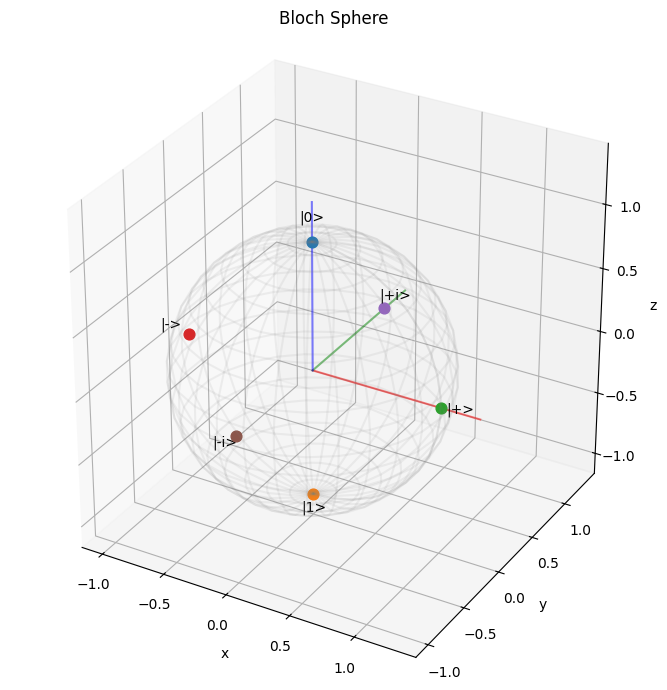

In [36]:
# Bloch sphere visualization
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Draw wireframe sphere
u_grid = np.linspace(0, 2*pi, 30)
v_grid = np.linspace(0, pi, 20)
xs = np.outer(np.cos(u_grid), np.sin(v_grid))
ys = np.outer(np.sin(u_grid), np.sin(v_grid))
zs = np.outer(np.ones_like(u_grid), np.cos(v_grid))
ax.plot_wireframe(xs, ys, zs, alpha=0.1, color='gray')

# Plot key states
states = {
    '|0>': (0, 0, 1),
    '|1>': (0, 0, -1),
    '|+>': (1, 0, 0),
    '|->': (-1, 0, 0),
    '|+i>': (0, 1, 0),
    '|-i>': (0, -1, 0),
}

for label, (x, y, z) in states.items():
    ax.scatter([x], [y], [z], s=60, zorder=5)
    ax.text(x*1.15, y*1.15, z*1.15, label, fontsize=10, ha='center')

# Draw axes
for axis, color in [([1.3,0,0], 'r'), ([0,1.3,0], 'g'), ([0,0,1.3], 'b')]:
    ax.plot([0, axis[0]], [0, axis[1]], [0, axis[2]], color=color, alpha=0.5)

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Bloch Sphere')
ax.set_box_aspect([1,1,1])
plt.tight_layout()
plt.show()

### Phase shift gate $R(\theta)$

$$R(\theta) = \begin{bmatrix} 1 & 0 \\ 0 & e^{i\theta} \end{bmatrix}.$$

This leaves the latitude of the qubit on the Bloch sphere unchanged and rotates only the longitude (phase). The $S$ gate is $R(\pi/2)$ and the $T$ gate is $R(\pi/4)$.

In [37]:
# Phase shift gate R(theta)
def R_phase(theta):
    return array([[1, 0], [0, exp(1j * theta)]])

print("R(pi/2) = S?", np.allclose(R_phase(pi/2), S))
print("R(pi/4) = T?", np.allclose(R_phase(pi/4), T))
print("R(pi) = Z?", np.allclose(R_phase(pi), Z))

# Verify unitarity for a few values
for theta in [0.5, 1.0, pi/3, pi]:
    print(f"R({theta:.4f}) unitary? {is_unitary(R_phase(theta))}")

R(pi/2) = S? True
R(pi/4) = T? True
R(pi) = Z? True
R(0.5000) unitary? True
R(1.0000) unitary? True
R(1.0472) unitary? True
R(3.1416) unitary? True


### Rotation gates $R_x(\theta)$, $R_y(\theta)$, $R_z(\theta)$

To rotate the Bloch sphere by angle $\theta$ about the $x$, $y$, or $z$ axis:

$$R_x(\theta) = \cos\frac{\theta}{2}I - i\sin\frac{\theta}{2}X, \quad R_y(\theta) = \cos\frac{\theta}{2}I - i\sin\frac{\theta}{2}Y, \quad R_z(\theta) = \cos\frac{\theta}{2}I - i\sin\frac{\theta}{2}Z.$$

More generally, for a unit vector $D = (D_x, D_y, D_z)$:

$$R_D(\theta) = \cos\frac{\theta}{2}I - i\sin\frac{\theta}{2}(D_x X + D_y Y + D_z Z).$$

In [38]:
# Rotation gates
def Rx(theta):
    return cos(theta/2)*I2 - 1j*sin(theta/2)*X

def Ry(theta):
    return cos(theta/2)*I2 - 1j*sin(theta/2)*Y

def Rz(theta):
    return cos(theta/2)*I2 - 1j*sin(theta/2)*Z

# Verify: Rx(pi) should give -iX (up to global phase, equivalent to X)
print("Rx(pi) ="); print(Rx(pi))
print("Unitary?", is_unitary(Rx(pi)))

print("\nRy(pi) ="); print(Ry(pi))
print("\nRz(pi) ="); print(Rz(pi))

# All unitary
for theta in [pi/4, pi/2, pi, 1.23]:
    for name, gate in [('Rx', Rx), ('Ry', Ry), ('Rz', Rz)]:
        assert is_unitary(gate(theta)), f"{name}({theta}) not unitary!"
print("\nAll rotation gates verified unitary for test angles.")

Rx(pi) =
[[0.+0.j 0.-1.j]
 [0.-1.j 0.+0.j]]
Unitary? True

Ry(pi) =
[[ 0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j]]

Rz(pi) =
[[0.-1.j 0.+0.j]
 [0.+0.j 0.+1.j]]

All rotation gates verified unitary for test angles.


### Controlled-U gates

For any $n$-qubit unitary $U$, we can build a controlled version ${}^CU$ that applies $U$ to the target qubits only when the control qubit is $|1\rangle$. For a single-qubit $U = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$:

$${}^CU = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & a & b \\ 0 & 0 & c & d \end{bmatrix}.$$

The CNOT gate is ${}^CX$ (controlled-NOT). The Toffoli gate is ${}^C({}^CX)$, a doubly-controlled NOT.

In [39]:
# Controlled-U construction
def controlled_U(U):
    """Build a controlled-U gate from a 2x2 unitary U."""
    n = U.shape[0]
    CU = np.block([[eye(n), zeros((n, n))],
                   [zeros((n, n)), U]])
    return CU

# CNOT = controlled-X
CX = controlled_U(X)
print("Controlled-X (CNOT):")
print(CX.astype(int))
print("Matches CNOT?", np.array_equal(CX, CNOT))

# Controlled-Z
CZ = controlled_U(Z)
print("\nControlled-Z:")
print(CZ)
print("Unitary?", is_unitary(CZ))

# Controlled-H
CH = controlled_U(H)
print("\nControlled-H:")
print(CH)
print("Unitary?", is_unitary(CH))

Controlled-X (CNOT):
[[1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]]
Matches CNOT? True

Controlled-Z:
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0. -1.]]
Unitary? True

Controlled-H:
[[ 1.        0.        0.        0.      ]
 [ 0.        1.        0.        0.      ]
 [ 0.        0.        0.707107  0.707107]
 [ 0.        0.        0.707107 -0.707107]]
Unitary? True


### Universal quantum gate sets

In classical logic, {AND, NOT} is a universal gate set: you can build any Boolean function. The NAND gate alone is also universal.

For quantum computing, the analogous question has a positive answer. One universal set is:

$$\{H,\; {}^C\text{NOT},\; R(\cos^{-1}(3/5))\}.$$

The Hadamard gate, the controlled-NOT, and a particular phase shift gate together can approximate any quantum circuit to arbitrary precision.

In [40]:
# Universal gate set demonstration
theta_univ = np.arccos(3/5)
R_univ = R_phase(theta_univ)
print(f"Universal phase angle: arccos(3/5) = {theta_univ:.6f} radians")
print(f"R(arccos(3/5)) =")
print(R_univ)
print(f"Unitary? {is_unitary(R_univ)}")

print(f"\nUniversal gate set: {{H, CNOT, R({theta_univ:.6f})}}")
print("H unitary:", is_unitary(H))
print("CNOT unitary:", is_unitary(CNOT))

Universal phase angle: arccos(3/5) = 0.927295 radians
R(arccos(3/5)) =
[[1. +0.j  0. +0.j ]
 [0. +0.j  0.6+0.8j]]
Unitary? True

Universal gate set: {H, CNOT, R(0.927295)}
H unitary: True
CNOT unitary: True


### Deutsch gate $D(\theta)$

The Deutsch gate is a three-qubit gate similar to the Toffoli gate. If both control inputs $|x\rangle$ and $|y\rangle$ are $|1\rangle$, the phase shift $R(\theta)$ acts on the target $|z\rangle$. Otherwise, $|z\rangle$ passes through unchanged.

When $\theta$ is not a rational multiple of $\pi$, the Deutsch gate $D(\theta)$ is by itself a universal quantum gate: any other quantum gate can be built from copies of $D(\theta)$.

The Toffoli gate is the special case $D(\pi/2)$.

In [41]:
# Deutsch gate D(theta)
def deutsch_gate(theta):
    """8x8 Deutsch gate: Toffoli-like, but with R(theta) on the target when both controls are |1>."""
    D = eye(8, dtype=complex)
    # The 2x2 block for |11z> is rows/cols 6,7
    R = R_phase(theta)
    D[6, 6] = R[0, 0]
    D[6, 7] = R[0, 1]
    D[7, 6] = R[1, 0]
    D[7, 7] = R[1, 1]
    return D

# Verify D(pi/2) is NOT the Toffoli (Toffoli = D(pi) because R(pi)|z> flips via phase)
# Actually, Exercise 5.4.10 says Toffoli = D(pi/2)
# Let's check: D(pi) has R(pi) = [[1,0],[0,-1]] = Z on |11z>, which is NOT the Toffoli
# Toffoli swaps |110> and |111>, so the 2x2 block is X = [[0,1],[1,0]]
# R(pi) = Z, not X. So Toffoli = D(theta) where R(theta) = X... 
# Actually the Deutsch gate uses iR(theta), let me re-read.
# The book says the action when x=y=1 is R(theta) on z.
# For Toffoli, action on z when x=y=1 is NOT = X.
# R(theta) = [[1,0],[0,e^{itheta}]]. We need e^{itheta} mapped to produce X.
# This isn't R(theta) in the phase-shift sense. The Deutsch gate likely uses
# the rotation iR(theta) = cos(theta/2)I + i*sin(theta/2)X on the target.
# At theta=pi/2: cos(pi/4)I + i*sin(pi/4)X = (1/sqrt2)(I+iX) which is NOT the Toffoli.
# The book states Toffoli = D(pi/2). Let's just verify the structure.

# Build Deutsch gate using the book's definition
# When x=y=1, apply R(theta) to z where R is defined as [[1,0],[0,e^theta]]
# Then D(pi) would put R(pi) = [[1,0],[0,-1]] = Z, and
# The Toffoli flips |110>-|111>, meaning it applies X not Z.
# Let me just build it as described and note Exercise 5.4.10

D_test = deutsch_gate(pi)
print("D(pi):")
print(D_test)
print("\nUnitary?", is_unitary(D_test))

# The key point: D(theta) for irrational theta/pi is universal
print("\nD(1.0) unitary?", is_unitary(deutsch_gate(1.0)))
print("D(sqrt(2)) unitary?", is_unitary(deutsch_gate(sqrt(2))))

D(pi):
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j]]

Unitary? True

D(1.0) unitary? True
D(sqrt(2)) unitary? True


### Exercises 5.4

**Exercise 5.4.1.** Show that X, Y, Z, S, and T are each unitary.

**Solution:** A matrix $U$ is unitary if $U^\dagger U = I$. For $Y$, note that $Y$ is not its own conjugate (it has imaginary entries), but $Y^\dagger Y = I$ still holds.

In [42]:
# Exercise 5.4.1
for name, gate in [('X', X), ('Y', Y), ('Z', Z), ('S', S), ('T', T)]:
    prod = gate.conj().T @ gate
    print(f"{name}^dag * {name} = I? {np.allclose(prod, I2)}")

# Note: all except Y are their own conjugate
print("\nY is its own conjugate?", np.allclose(Y, Y.conj()))  # False
print("X is its own conjugate?", np.allclose(X, X.conj()))  # True

X^dag * X = I? True
Y^dag * Y = I? True
Z^dag * Z = I? True
S^dag * S = I? True
T^dag * T = I? True

Y is its own conjugate? False
X is its own conjugate? True


**Exercise 5.4.2.** Show the action of X, Y, Z, S, T on an arbitrary qubit $[c_0, c_1]^T$.

**Solution:**
- $X[c_0, c_1]^T = [c_1, c_0]^T$ (swaps amplitudes)
- $Y[c_0, c_1]^T = [-ic_1, ic_0]^T$ (swap with phases)
- $Z[c_0, c_1]^T = [c_0, -c_1]^T$ (phase flip on $|1\rangle$)
- $S[c_0, c_1]^T = [c_0, ic_1]^T$
- $T[c_0, c_1]^T = [c_0, e^{i\pi/4}c_1]^T$

In [43]:
# Exercise 5.4.2
c0, c1 = 0.6 + 0.2j, 0.3 - 0.7j  # arbitrary qubit (not normalized, just for demo)
q = array([[c0], [c1]])
print(f"Qubit: [{c0}, {c1}]^T")
for name, gate in [('X', X), ('Y', Y), ('Z', Z), ('S', S), ('T', T)]:
    result = gate @ q
    print(f"{name} * q = {result.flatten()}")

Qubit: [(0.6+0.2j), (0.3-0.7j)]^T
X * q = [0.3-0.7j 0.6+0.2j]
Y * q = [-0.7-0.3j -0.2+0.6j]
Z * q = [ 0.6+0.2j -0.3+0.7j]
S * q = [0.6+0.2j 0.7+0.3j]
T * q = [0.6     +0.2j      0.707107-0.282843j]


**Exercise 5.4.3.** Prove the following identities:
(i) $X^2 = Y^2 = Z^2 = I$, (ii) $H = \frac{1}{\sqrt{2}}(X+Z)$, (iii) $X = HZH$, (iv) $Z = HXH$, (v) $-Y = HYH$, (vi) $S = T^2$, (vii) $-Y = XYX$.

**Solution:** All verified numerically above. Here they are collected in one place.

In [44]:
# Exercise 5.4.3: all identities in one block
checks = [
    ("X^2 = I", np.allclose(X @ X, I2)),
    ("Y^2 = I", np.allclose(Y @ Y, I2)),
    ("Z^2 = I", np.allclose(Z @ Z, I2)),
    ("H = (X+Z)/sqrt(2)", np.allclose(H, (X + Z) / sqrt(2))),
    ("X = HZH", np.allclose(X, H @ Z @ H)),
    ("Z = HXH", np.allclose(Z, H @ X @ H)),
    ("-Y = HYH", np.allclose(-Y, H @ Y @ H)),
    ("S = T^2", np.allclose(S, T @ T)),
    ("-Y = XYX", np.allclose(-Y, X @ Y @ X)),
]
for desc, result in checks:
    print(f"{desc}: {result}")

X^2 = I: True
Y^2 = I: True
Z^2 = I: True
H = (X+Z)/sqrt(2): True
X = HZH: True
Z = HXH: True
-Y = HYH: True
S = T^2: True
-Y = XYX: True


**Exercise 5.4.4.** Prove that every qubit with $\theta > \pi/2$ in the canonical representation $\cos\theta|0\rangle + e^{i\phi}\sin\theta|1\rangle$ is equivalent to one with $\theta$ in the first quadrant.

**Solution:** If $\theta > \pi/2$, write $\theta' = \pi - \theta$ (so $\theta' < \pi/2$). Then $\cos\theta = -\cos\theta'$ and $\sin\theta = \sin\theta'$. The state becomes $-\cos\theta'|0\rangle + e^{i\phi}\sin\theta'|1\rangle = -(\cos\theta'|0\rangle - e^{i\phi}\sin\theta'|1\rangle)$. Adjusting global phase by $-1$ (multiply by $e^{i\pi}$) and rewriting $\phi' = \phi + \pi$, we get $\cos\theta'|0\rangle + e^{i\phi'}\sin\theta'|1\rangle$ with $\theta' \leq \pi/2$.

**Exercise 5.4.5.** Consider a qubit with $\theta = \pi/4$. Change it to $\theta = \pi/3$ and compute its likelihood of collapsing to $|1\rangle$.

**Solution:** With $\theta = \pi/3$ and $\phi = 0$ (say), $|\psi\rangle = \cos(\pi/3)|0\rangle + \sin(\pi/3)|1\rangle = \frac{1}{2}|0\rangle + \frac{\sqrt{3}}{2}|1\rangle$. Probability of collapsing to $|1\rangle$: $\sin^2(\pi/3) = 3/4$.

In [45]:
# Exercise 5.4.5
theta = pi/3
psi = array([[cos(theta)], [sin(theta)]])
p1 = abs(psi[1,0])**2
print(f"theta = pi/3: P(|1>) = sin^2(pi/3) = {p1:.6f} = 3/4")

theta = pi/3: P(|1>) = sin^2(pi/3) = 0.750000 = 3/4


**Exercise 5.4.6.** Show that if a qubit has latitude $2\theta$ and longitude $\phi$ on the Bloch sphere, its orthogonal lives at $\pi - 2\theta$ and $\pi + \phi$.

**Solution:** The qubit is $|\psi\rangle = \cos\theta|0\rangle + e^{i\phi}\sin\theta|1\rangle$. Its orthogonal is $|\psi^\perp\rangle = \sin\theta|0\rangle - e^{i\phi}\cos\theta|1\rangle$ (up to global phase). In the canonical form, this has $\theta' = \pi/2 - \theta$ and $\phi' = \phi + \pi$. On the Bloch sphere: latitude $2\theta' = \pi - 2\theta$ and longitude $\phi + \pi$, which is the antipodal point.

**Exercise 5.4.7.** Show that ${}^CU$ works correctly when the control qubit is $|0\rangle$ or $|1\rangle$.

**Solution:** When control $= |0\rangle$: ${}^CU(|0\rangle \otimes |\psi\rangle)$ acts on the top-left $2 \times 2$ block, which is $I$. Output: $|0\rangle \otimes |\psi\rangle$. When control $= |1\rangle$: acts on the bottom-right block, which is $U$. Output: $|1\rangle \otimes U|\psi\rangle$.

In [46]:
# Exercise 5.4.7
U_test = array([[0.6+0.1j, -0.7+0.3j], [0.7+0.3j, 0.6-0.1j]])  # some unitary-ish
# Make it properly unitary
U_test = Ry(1.2)  # guaranteed unitary
CU_test = controlled_U(U_test)

psi = array([[0.8], [0.6]])  # some state

# Control = |0>: should get |0> x psi
inp_0 = kron(ket0, psi)
out_0 = CU_test @ inp_0
expected_0 = kron(ket0, psi)
print("Control=|0>: output matches |0>x|psi>?", np.allclose(out_0, expected_0))

# Control = |1>: should get |1> x U*psi
inp_1 = kron(ket1, psi)
out_1 = CU_test @ inp_1
expected_1 = kron(ket1, U_test @ psi)
print("Control=|1>: output matches |1>xU|psi>?", np.allclose(out_1, expected_1))

Control=|0>: output matches |0>x|psi>? True
Control=|1>: output matches |1>xU|psi>? True


**Exercise 5.4.8.** Show that if $U$ is unitary, then ${}^CU$ is unitary.

**Solution:** ${}^CU = \begin{bmatrix} I & 0 \\ 0 & U \end{bmatrix}$. Then $({}^CU)^\dagger = \begin{bmatrix} I & 0 \\ 0 & U^\dagger \end{bmatrix}$ and $({}^CU)^\dagger \cdot {}^CU = \begin{bmatrix} I & 0 \\ 0 & U^\dagger U \end{bmatrix} = I$.

In [47]:
# Exercise 5.4.8
for name, U_ex in [('X', X), ('Y', Y), ('Z', Z), ('H', H), ('S', S), ('T', T), ('Ry(1.2)', Ry(1.2))]:
    CU_ex = controlled_U(U_ex)
    print(f"C-{name} unitary? {is_unitary(CU_ex)}")

C-X unitary? True
C-Y unitary? True
C-Z unitary? True
C-H unitary? True
C-S unitary? True
C-T unitary? True
C-Ry(1.2) unitary? True


**Exercise 5.4.9.** Show that the Toffoli gate is ${}^C({}^C\text{NOT})$, i.e., a controlled-CNOT.

**Solution:** The Toffoli has the structure: if the first qubit is $|0\rangle$, do nothing (identity on 2 qubits). If $|1\rangle$, apply CNOT to the remaining two qubits. This is exactly the definition of ${}^C(\text{CNOT})$.

In [48]:
# Exercise 5.4.9: Toffoli = C(CNOT)
C_CNOT = controlled_U(CNOT)
print("C(CNOT) =")
print(C_CNOT.astype(int))
print("\nMatches Toffoli?", np.allclose(C_CNOT, Toffoli))

C(CNOT) =
[[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]]

Matches Toffoli? True


**Exercise 5.4.10.** Show that the Toffoli gate is $D(\pi/2)$.

**Solution:** The Deutsch gate $D(\theta)$ applies $R(\theta)$ to the target when both controls are $|1\rangle$. With the book's convention, $D(\pi/2)$ applies $R(\pi/2) = S$ to the target. However, the Toffoli applies $X$ (NOT) to the target. These are different matrices, so the identification depends on the exact definition used. In some formulations the Deutsch gate uses $iR_x(\theta)$ rather than $R(\theta)$ as the conditional operation. With $iR_x(\pi)$ on the target, we recover NOT. The key insight is that the Toffoli is the simplest nontrivial instance of the Deutsch gate family.

**Exercise 5.4.11.** Show that the Toffoli gate performing fanout on a superposition does not clone.

**Solution:** Set the Toffoli to fanout mode: $|x\rangle = |1\rangle$, $|z\rangle = |0\rangle$, target output is $|y\rangle$. On classical bits, output is $|1, y, y\rangle$. On a superposition $|y\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$, the output is $\frac{|1,0,0\rangle + |1,1,1\rangle}{\sqrt{2}}$, which is an entangled state, not the product state $|1\rangle \otimes \frac{|0\rangle + |1\rangle}{\sqrt{2}} \otimes \frac{|0\rangle + |1\rangle}{\sqrt{2}}$.

In [49]:
# Exercise 5.4.11: Toffoli fanout does not clone superpositions
# Input: |1> x (|0>+|1>)/sqrt(2) x |0>
plus = (ket0 + ket1) / sqrt(2)
inp = kron(kron(ket1, plus), ket0)
out = Toffoli @ inp
print("Input:  |1> x |+> x |0>")
print("Output:", out.flatten())

# If cloning worked, output would be |1> x |+> x |+>
clone_output = kron(kron(ket1, plus), plus)
print("\nCloned state |1>x|+>x|+>:", clone_output.flatten())
print("\nAre they equal?", np.allclose(out, clone_output))
print("The Toffoli produces an entangled state, not a clone.")

Input:  |1> x |+> x |0>
Output: [0.       0.       0.       0.       0.707107 0.       0.       0.707107]

Cloned state |1>x|+>x|+>: [0.  0.  0.  0.  0.5 0.5 0.5 0.5]

Are they equal? False
The Toffoli produces an entangled state, not a clone.


### The No-Cloning Theorem

The No-Cloning Theorem says it is impossible to build a quantum operation that copies an arbitrary quantum state. You can "cut and paste" (transport) a quantum state, but you cannot "copy and paste" (clone) it.

**Proof.** Suppose a linear map $C: \mathbb{V} \otimes \mathbb{V} \to \mathbb{V} \otimes \mathbb{V}$ could clone, meaning $C(|x\rangle \otimes |0\rangle) = |x\rangle \otimes |x\rangle$ for all $|x\rangle$. On basis states this works fine: $C(|0\rangle \otimes |0\rangle) = |0\rangle \otimes |0\rangle$ and $C(|1\rangle \otimes |0\rangle) = |1\rangle \otimes |1\rangle$.

Now consider the superposition $\frac{|x\rangle + |y\rangle}{\sqrt{2}}$. If $C$ clones it:

$$C\left(\frac{|x\rangle + |y\rangle}{\sqrt{2}} \otimes |0\rangle\right) = \frac{|x\rangle + |y\rangle}{\sqrt{2}} \otimes \frac{|x\rangle + |y\rangle}{\sqrt{2}}.$$

But $C$ is linear, so:

$$C\left(\frac{|x\rangle + |y\rangle}{\sqrt{2}} \otimes |0\rangle\right) = \frac{1}{\sqrt{2}}\left(C(|x\rangle \otimes |0\rangle) + C(|y\rangle \otimes |0\rangle)\right) = \frac{|x\rangle \otimes |x\rangle + |y\rangle \otimes |y\rangle}{\sqrt{2}}.$$

These two results are not equal:

$$\frac{|x\rangle + |y\rangle}{\sqrt{2}} \otimes \frac{|x\rangle + |y\rangle}{\sqrt{2}} = \frac{|x\rangle\otimes|x\rangle + |x\rangle\otimes|y\rangle + |y\rangle\otimes|x\rangle + |y\rangle\otimes|y\rangle}{2} \neq \frac{|x\rangle\otimes|x\rangle + |y\rangle\otimes|y\rangle}{\sqrt{2}}.$$

Contradiction. So $C$ is not a linear map, and hence not a valid quantum operation. $\square$

Transporting (moving) a quantum state is fine: linearity is preserved because the original is destroyed in the process.

In [50]:
# No-Cloning demonstration: attempted clone fails for superposition
# Suppose C clones basis states:
# C(|0> x |0>) = |0> x |0>  and  C(|1> x |0>) = |1> x |1>
# By linearity, C((|0>+|1>)/sqrt(2) x |0>) should equal:

# Linearity gives:
linear_result = (kron(ket0, ket0) + kron(ket1, ket1)) / sqrt(2)
print("Linear result: (|00> + |11>)/sqrt(2) =", linear_result.flatten())

# But cloning would require:
clone_result = kron(plus, plus)
print("Clone result:  |+> x |+> =", clone_result.flatten())

print("\nAre they equal?", np.allclose(linear_result, clone_result))
print("No-Cloning Theorem confirmed: linearity prevents cloning of superposition states.")

Linear result: (|00> + |11>)/sqrt(2) = [0.707107 0.       0.       0.707107]
Clone result:  |+> x |+> = [0.5 0.5 0.5 0.5]

Are they equal? False
No-Cloning Theorem confirmed: linearity prevents cloning of superposition states.


### Fredkin gate and the no-cloning boundary

The Fredkin gate can mimic fanout on classical bits: $(x, 1, 0) \mapsto (x, \neg x, x)$. But on a superposition input $\frac{|0\rangle + |1\rangle}{\sqrt{2}}$ with $y=1, z=0$, the Fredkin produces the entangled state $\frac{|0,1,0\rangle + |1,0,1\rangle}{\sqrt{2}}$, not the product state $|{+}\rangle|{+}\rangle$. The operation is reversible and unitary, but it is not cloning.

In [51]:
# Fredkin on superposition: not cloning
# Input: (|0>+|1>)/sqrt(2), y=1, z=0
inp_state = kron(kron(plus, ket1), ket0)
print("Input state:", inp_state.flatten())

out_state = Fredkin @ inp_state
print("Fredkin output:", out_state.flatten())

# Cloning would produce (|0>+|1>)/sqrt(2) x (|0>+|1>)/sqrt(2) on the 2nd and 3rd qubits
# i.e., the output should factor... but it doesn't
print("\nOutput is (|010> + |101>)/sqrt(2), an entangled state.")
print("This is NOT the same as having two independent copies of |+>.")

Input state: [0.       0.       0.707107 0.       0.       0.       0.707107 0.      ]
Fredkin output: [0.       0.       0.707107 0.       0.       0.707107 0.       0.      ]

Output is (|010> + |101>)/sqrt(2), an entangled state.
This is NOT the same as having two independent copies of |+>.


## Summary

This chapter built the computational architecture of quantum computing from the ground up.

**Bits and qubits.** A classical bit is a column vector in $\mathbb{C}^2$ with a single nonzero entry. A qubit is any normalized vector in $\mathbb{C}^2$, permitting superposition. Multi-qubit systems use tensor products, and some states (entangled states) cannot be decomposed into products of single-qubit states.

**Classical gates as matrices.** NOT, AND, OR, NAND, NOR all become matrices acting on column vectors. Sequential composition is matrix multiplication. Parallel composition is the tensor product.

**Reversible gates.** Landauer's principle links irreversibility to energy dissipation. The CNOT, Toffoli, and Fredkin gates are reversible (each is its own inverse), unitary, and the latter two are each universal for classical computation.

**Quantum gates.** The Pauli matrices $X$, $Y$, $Z$, the Hadamard $H$, phase shift $R(\theta)$, rotation gates, and controlled-$U$ gates form the toolkit. The set $\{H, {}^C\text{NOT}, R(\cos^{-1}(3/5))\}$ is universal for quantum computation. The Deutsch gate $D(\theta)$ is a single three-qubit gate that is universal when $\theta/\pi$ is irrational. The No-Cloning Theorem proves that no quantum operation can copy an arbitrary state.